In [35]:
from src.gmm import GMM
from src.dg import DataGenerator

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, logistic, t

import torch


## Data generating

In [36]:
# param_vals
dist = 'Logistic' # Logistic, Normal, Student t
alpha = 0.7
d = 3
N = 2000

#df = 3 # for Student t in particular

dg = DataGenerator(dist, alpha)
X, M = dg.generate(N, d)

In [37]:
def true_quantile(dist, q=0.1, df=None):
    if dist == 'Normal':
        return norm.ppf(q)
    elif dist == 'Logistic':
        return logistic.ppf(q)
    elif dist == 'Student t':
        return t.ppf(q, df)

## Iterative EM

In [38]:
# GMM settings
cov_type = 'uni_diag' # diag, id, uni_diag, uni_id
n_k = 5
start = 0
step = 1
n_mc = 500
n_samples = 2000

In [39]:
gmm = GMM(X, M, cov_type)
mu, sigma, pi, kk, q, loglik, aic, bic = gmm.iterEM(n_k, start, step, n_mc, n_samples)

0 1.00 -9593.70 19199.40 19233.00
Converged at iteration 1, rel_change=0.00e+00
1 2.00 -9593.70 19207.40 19263.41
Converged at iteration 1, rel_change=0.00e+00
2 3.00 -9593.70 19215.40 19293.81
Converged at iteration 1, rel_change=0.00e+00
3 4.00 -9593.70 19223.40 19324.21
Converged at iteration 1, rel_change=0.00e+00
4 5.00 -9593.70 19231.40 19354.62


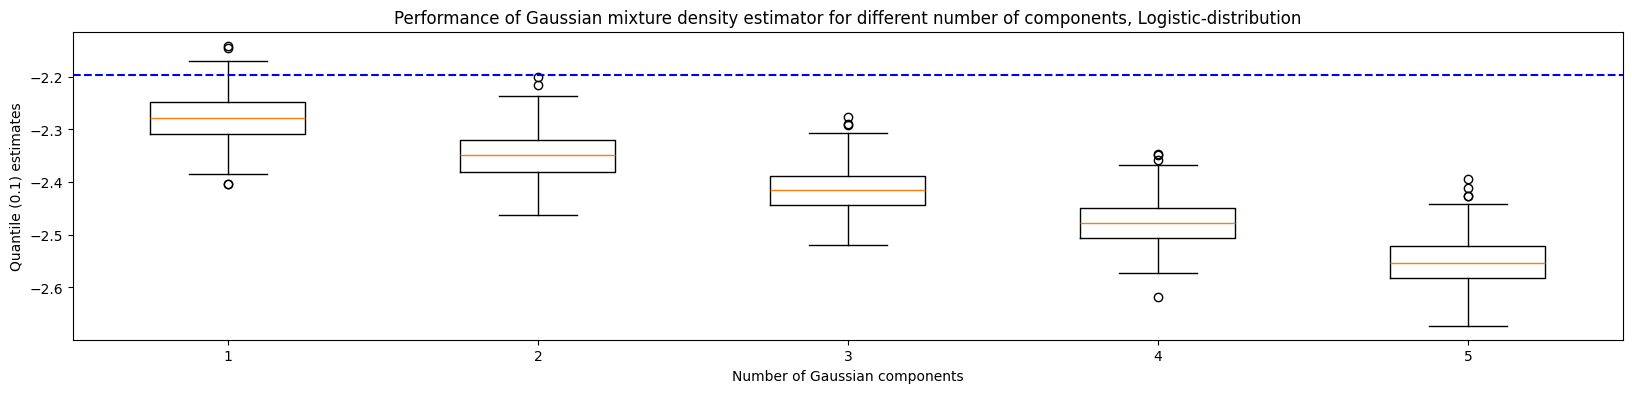

In [40]:
positions = np.array(kk)

plt.figure(figsize=(20, 4))
plt.boxplot(q.T, positions=positions)

plt.axhline(y=true_quantile(dist), color='blue', linestyle='--')
plt.xlabel("Number of Gaussian components")
plt.ylabel("Quantile (0.1) estimates")
plt.xticks(positions, positions.astype(int))
plt.title(f'Performance of Gaussian mixture density estimator for different number of components, {dist}-distribution')
plt.show()

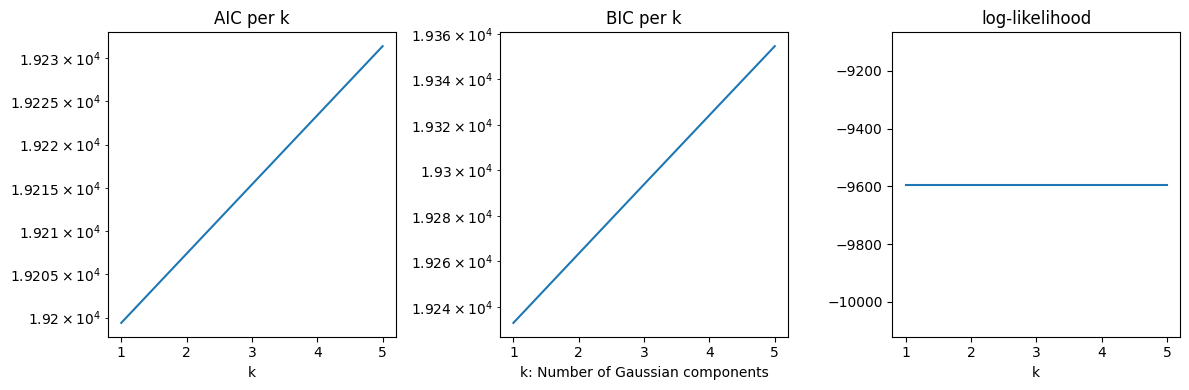

In [41]:
fig, axs = plt.subplots(1, 3, figsize=(12, 4))

axs[0].plot(kk, aic)
axs[0].set_yscale('log')
axs[0].set_xlabel('k')
axs[0].set_title('AIC per k')

axs[1].plot(kk, bic)
axs[1].set_yscale('log')
axs[1].set_xlabel('k: Number of Gaussian components')
axs[1].set_title('BIC per k')

axs[2].plot(kk, loglik)
axs[2].set_xlabel('k')
axs[2].set_title('log-likelihood')

plt.tight_layout()
plt.show()

In [42]:
def energy_distance(X, Y):
    """
    Compute the (squared) energy distance between two samples X ~ P, Y ~ Q.
    X: tensor of shape (n, d)
    Y: tensor of shape (m, d)
    
    E(P, Q) = 2 * E||X - Y|| - E||X - X'|| - E||Y - Y'||
    """
    X = X.double()
    Y = Y.double()

    n, m = X.shape[0], Y.shape[0]

    # Pairwise distances
    d_XY = torch.cdist(X, Y, p=2)      # (n, m)
    d_XX = torch.cdist(X, X, p=2)      # (n, n)
    d_YY = torch.cdist(Y, Y, p=2)      # (m, m)

    term_XY = d_XY.mean()

    # exclude diagonal (i.e. X_i vs X_i, which is 0 and shouldn't bias things,
    # but standard practice is to use the unbiased version excluding self-pairs)
    term_XX = (d_XX.sum() - d_XX.diagonal().sum()) / (n * (n - 1))
    term_YY = (d_YY.sum() - d_YY.diagonal().sum()) / (m * (m - 1))

    return 2 * term_XY - term_XX - term_YY


# Example usage:
# data: tensor of shape (n, 3)
# samples: sample_gmm(mu, sigma, pi, param_vals['n_new'])  -> tensor of shape (m, 3)

ed = energy_distance(X, gmm.sample_gmm(mu, sigma, pi, n_samples))
print(f"Energy distance: {ed.item():.4f}")

Energy distance: 0.1506
